In [7]:
import pandas as pd
df = pd.read_csv("/home/abishek-murugan/Project Folder/GUVI Projects/EcoType-Forest-Cover/data/processed/feature_engineered_forest_cover_data.csv")

from sklearn.model_selection import train_test_split

x = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

X_train, X_test, Y_train, Y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
    )

rf.fit(X_train, Y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [9]:
from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9578106792789087

In [10]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
0,Elevation,0.251859
5,Horizontal_Distance_To_Roadways,0.116192
9,Horizontal_Distance_To_Fire_Points,0.098831
16,Road_Fire_Distance_Ratio,0.088817
11,Soil_Type,0.075980
10,Wilderness_Area,0.068252
15,Hydrology_Distance_Mag,0.042871
4,Vertical_Distance_To_Hydrology,0.040104
3,Horizontal_Distance_To_Hydrology,0.034773
1,Aspect,0.028043


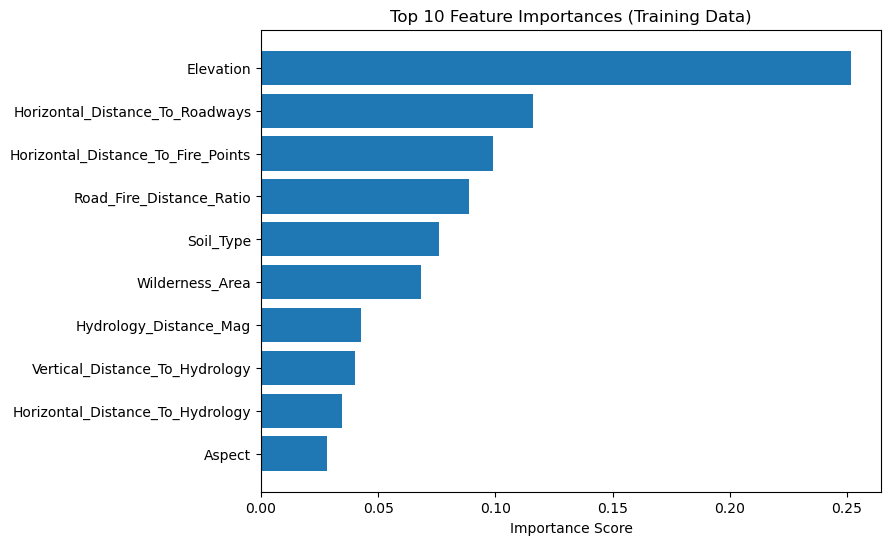

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(
    feature_importance['Feature'][:10][::-1],
    feature_importance['Importance'][:10][::-1]
)
plt.title("Top 10 Feature Importances (Training Data)")
plt.xlabel("Importance Score")
plt.show()

In [11]:
threshold = 0.01
selected_features = feature_importance[
    feature_importance['Importance'] > threshold
]['Feature'].tolist()

len(selected_features)
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [12]:
rf.fit(X_train_selected, y_train)
y_pred = rf.predict(X_test_selected)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)


from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)


0.9582562204400575